<div style="
    background: linear-gradient(90deg, #0d9488, #06b6d4);
    padding: 60px 20px;
    margin: 40px auto;
    border-radius: 18px;
    box-shadow: 0 3px 6px rgba(0, 0, 0, 0.3);
    border: 4px solid #ffffff;
    text-align: center;
    width: 95%;
">
    <h1 style="color: white; font-family: Arial Black; font-size: 50px; font-weight: 900; margin: 0; text-shadow: 2px 2px 5px rgba(0,0,0,0.7);">
        Heart Disease Prediction
    </h1>
    <p style="color: #ccfbf1; font-size: 20px; margin-top: 15px;">Playground Series S6E2</p>
</div>

This notebook uses the **RealMLP (Regularized MLP)** model from the `pytabkit` library to predict heart disease. The key features include:

- **External Data Feature Engineering**: Target statistics (mean, median, std, skew, count) from the original UCI dataset
- **5-Fold Stratified Cross-Validation**
- **Optimized Hyperparameters** for best performance

| Column Name | Description | Type | Typical Range / Values | Clinical Relevance |
|-------------|-------------|------|------------------------|--------------------|
| 🧓 **Age** | Age of the patient in years | Numeric | 29–77 | Risk increases after age 45 (men) / 55 (women) |
| 🚹 **Sex** | Gender of the patient | Binary | 1=Male, 0=Female | Men have higher risk at younger ages |
| 💔 **Chest pain type** | Type of chest pain experienced | Categorical | 1–4 | Typical angina (1) and Asymptomatic (4) indicate higher risk |
| 💉 **BP** | Resting blood pressure | Numeric | 94–200 mm Hg | Hypertension (>140/90) is a major risk factor |
| 🧈 **Cholesterol** | Serum cholesterol level | Numeric | 126–564 mg/dL | High levels (>200-240) promote plaque buildup |
| 🍬 **FBS over 120** | Fasting blood sugar > 120 mg/dL | Binary | 1=True, 0=False | Diabetes is a strong CAD risk factor |
| 📈 **EKG results** | Resting ECG results | Categorical | 0–2 | Indicates possible ischemia or structural changes |
| ❤️ **Max HR** | Maximum heart rate achieved | Numeric | 71–202 bpm | Lower max HR indicates poor cardiac reserve |
| 🏃 **Exercise angina** | Exercise-induced angina | Binary | 1=Yes, 0=No | Very specific sign of ischemia |
| 📉 **ST depression** | ST depression during exercise | Numeric | 0.0–6.2 | Values ≥1.0 mm are often diagnostic |
| ⛰️ **Slope of ST** | Slope of peak exercise ST segment | Categorical | 1–3 | Downsloping (3) indicates severe ischemia |
| 🩸 **Number of vessels fluro** | Major coronary vessels colored by fluoroscopy | Ordinal | 0–3 | Higher values = more severe CAD |
| 🧬 **Thallium** | Thallium stress test result | Categorical | 3,6,7 | Reversible defects indicate ischemia |
| 🎯 **Heart Disease** | Target variable | Binary | Presence/Absence | ≥50% narrowing in at least one major artery |

# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>1. Import Libraries</b></div>

In [1]:
!pip install pytabkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 7.9 MB/s eta 0:00:00


In [2]:
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>2. Global Configuration</b></div>

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
N_FOLDS = 5

print(f"Using device: {DEVICE}")

Using device: cuda


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>3. Data Loading and Preprocessing</b></div>

In [4]:
train = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")
original = pd.read_csv("/kaggle/input/heartdisease/Heart_Disease_Prediction.csv") 

le = LabelEncoder()
train['Heart Disease'] = le.fit_transform(train['Heart Disease'])
original['Heart Disease'] = le.fit_transform(original['Heart Disease'])

base_features = [col for col in train.columns if col not in ['Heart Disease', 'id']] 

def add_engineered_features(df):
    df_temp = df.copy()
    initial_rows = len(df_temp)
    
    for col in base_features: 
        if col in original.columns:
           
            stats = original.groupby(col)['Heart Disease'].agg(['mean', 'median', 'std', 'skew', 'count']).reset_index()
         
            stats.columns = [col] + [f"orig_{col}_{s}" for s in ['mean', 'median', 'std', 'skew', 'count']]
     
            df_temp = df_temp.merge(stats, on=col, how='left') 
            if len(df_temp) != initial_rows:
                raise ValueError(f"Merge expanded rows for column {col}! Initial: {initial_rows}, Current: {len(df_temp)}")
 
            fill_values = {
                f"orig_{col}_mean": original['Heart Disease'].mean(),
                f"orig_{col}_median": original['Heart Disease'].median(),
                f"orig_{col}_std": 0,
                f"orig_{col}_skew": 0,
                f"orig_{col}_count": 0
            }
            df_temp = df_temp.fillna(value=fill_values)
            
    return df_temp

train = add_engineered_features(train)
test = add_engineered_features(test) 

print(f'Train Shape after FE: {train.shape}')
print(f'Test Shape after FE: {test.shape}')

if len(train) != 630000:
    print("WARNING: Train row count mismatch!")
if len(test) != 270000:
    print("WARNING: Test row count mismatch!")

X = train.drop(['id', 'Heart Disease'], axis=1)
y = train['Heart Disease']
X_test = test.drop(['id'], axis=1)

print(f'Train Shape: {train.shape}')
print(f'Test Shape: {test.shape}')
print(f'X Shape: {X.shape}')
print(f'X_test Shape: {X_test.shape}')

Train Shape after FE: (630000, 80)
Test Shape after FE: (270000, 79)
Train Shape: (630000, 80)
Test Shape: (270000, 79)
X Shape: (630000, 78)
X_test Shape: (270000, 78)


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>4. Data Quality Check</b></div>

In [5]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()
    
    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>5. Feature Uniqueness & Cardinality</b></div>

In [6]:
def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id': continue
        
        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"
        
        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess
        })
    
    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

uniqueness_df = analyze_uniqueness(train)
uniqueness_df

,Feature,Unique Values,Data Type,Heuristic Type
40,orig_FBS over 120_median,1,float64,Categorical/Ordinal
1,Sex,2,int64,Categorical/Ordinal
13,Heart Disease,2,int64,Categorical/Ordinal
5,FBS over 120,2,int64,Categorical/Ordinal
20,orig_Sex_median,2,float64,Categorical/Ordinal
...,...,...,...,...
0,Age,42,int64,Continuous
3,BP,66,int64,Continuous
9,ST depression,66,float64,Continuous
7,Max HR,93,int64,Continuous


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>6. Visualize Top Skewed Features</b></div>

Top 6 Most Skewed Features (Absolute Values):
orig_EKG results_count   -15.613416
orig_EKG results_std       6.747575
orig_Slope of ST_count    -5.657311
orig_Thallium_std          4.472673
orig_BP_std               -4.174508
orig_Age_std              -3.145546
dtype: float64


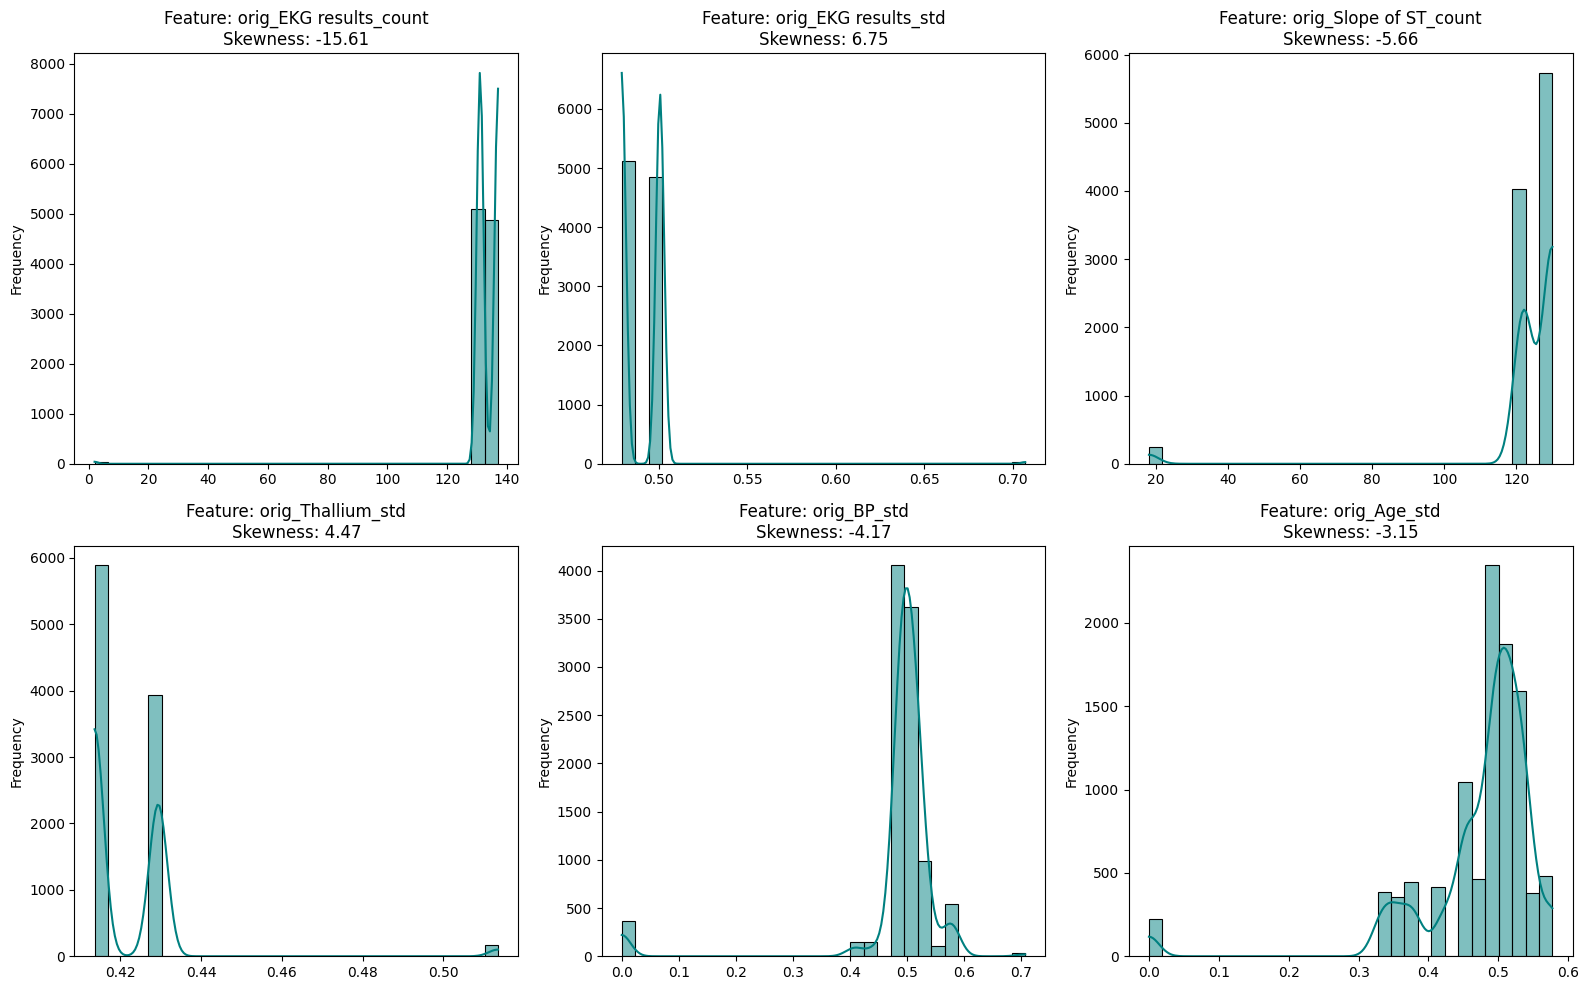

In [7]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1) 
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>7. Cross-Validation & Training</b></div>

In [8]:
%%time

param_grid = {
        'device': 'cuda',
        'random_state': 42,
        'verbosity': 2,
        'n_epochs': 100,
        'batch_size': 256, 
        'n_ens': 8, 
        'use_early_stopping': True,
        'early_stopping_additive_patience': 20,
        'early_stopping_multiplicative_patience': 1,
        'act': "mish",
        'embedding_size': 8,
        'first_layer_lr_factor': 0.5962121993798933,
        'hidden_sizes': "rectangular",
        'hidden_width': 384,
        'lr': 0.04, 
        'ls_eps': 0.011498317194338772,
        'ls_eps_sched': "coslog4",
        'max_one_hot_cat_size': 18,
        'n_hidden_layers': 4, 
        'p_drop': 0.07301419697186451,
        'p_drop_sched': "flat_cos",
        'plr_hidden_1': 16, 
        'plr_hidden_2': 8,
        'plr_lr_factor': 0.1151437622270563,
        'plr_sigma': 2.3316811282666916,
        'scale_lr_factor': 2.244801835541429,
        'sq_mom': 1.0 - 0.011834054955582318,
        'wd': 0.02369230879235962,
    } 

for col in X.columns:
    X[col] = X[col].astype(str).astype('category')
    X_test[col] = X_test[col].astype(str).astype('category') 

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))
fold_scores = [] 

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Starting Fold {fold + 1} ---")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx] 

    model = RealMLP_TD_Classifier(**param_grid) 
    model.fit(X_tr, y_tr.values, X_val, y_val.values) 

    val_probs = model.predict_proba(X_val)[:, 1] 
    fold_test_probs = model.predict_proba(X_test)[:, 1] 

    oof_preds[val_idx] = val_probs
    test_preds += fold_test_probs / N_FOLDS

    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold + 1} ROC-AUC Score: {score:.5f}")

    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


--- Starting Fold 1 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 'orig_EKG results_median', 'or

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val class_error = 0.110476
Epoch 2/100: val class_error = 0.110063
Epoch 3/100: val class_error = 0.111008
Epoch 4/100: val class_error = 0.110071
Epoch 5/100: val class_error = 0.109698
Epoch 6/100: val class_error = 0.109040
Epoch 7/100: val class_error = 0.109008
Epoch 8/100: val class_error = 0.109627
Epoch 9/100: val class_error = 0.109571
Epoch 10/100: val class_error = 0.109667
Epoch 11/100: val class_error = 0.109937
Epoch 12/100: val class_error = 0.109643
Epoch 13/100: val class_error = 0.109786
Epoch 14/100: val class_error = 0.109579
Epoch 15/100: val class_error = 0.109841
Epoch 16/100: val class_error = 0.109405
Epoch 17/100: val class_error = 0.109611
Epoch 18/100: val class_error = 0.109095
Epoch 19/100: val class_error = 0.109175
Epoch 20/100: val class_error = 0.109254
Epoch 21/100: val class_error = 0.109190
Epoch 22/100: val class_error = 0.109286
Epoch 23/100: val class_error = 0.109373
Epoch 24/100: val class_error = 0.109627
Epoch 25/100: val class_e

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Fold 1 ROC-AUC Score: 0.95608

--- Starting Fold 2 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 

...

Fold 4 ROC-AUC Score: 0.95548

--- Starting Fold 5 ---
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'orig_Age_mean', 'orig_Age_median', 'orig_Age_std', 'orig_Age_skew', 'orig_Age_count', 'orig_Sex_mean', 'orig_Sex_median', 'orig_Sex_std', 'orig_Sex_skew', 'orig_Sex_count', 'orig_Chest pain type_mean', 'orig_Chest pain type_median', 'orig_Chest pain type_std', 'orig_Chest pain type_skew', 'orig_Chest pain type_count', 'orig_BP_mean', 'orig_BP_median', 'orig_BP_std', 'orig_BP_skew', 'orig_BP_count', 'orig_Cholesterol_mean', 'orig_Cholesterol_median', 'orig_Cholesterol_std', 'orig_Cholesterol_skew', 'orig_Cholesterol_count', 'orig_FBS over 120_mean', 'orig_FBS over 120_median', 'orig_FBS over 120_std', 'orig_FBS over 120_skew', 'orig_FBS over 120_count', 'orig_EKG results_mean', 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 1/100: val class_error = 0.111421
Epoch 2/100: val class_error = 0.110968
Epoch 3/100: val class_error = 0.112373
Epoch 4/100: val class_error = 0.111333
Epoch 5/100: val class_error = 0.110556
Epoch 6/100: val class_error = 0.110492
Epoch 7/100: val class_error = 0.110389
Epoch 8/100: val class_error = 0.110976
Epoch 9/100: val class_error = 0.110643
Epoch 10/100: val class_error = 0.110825
Epoch 11/100: val class_error = 0.111484
Epoch 12/100: val class_error = 0.111365
Epoch 13/100: val class_error = 0.110802
Epoch 14/100: val class_error = 0.110675
Epoch 15/100: val class_error = 0.110603
Epoch 16/100: val class_error = 0.110587
Epoch 17/100: val class_error = 0.110357
Epoch 18/100: val class_error = 0.110516
Epoch 19/100: val class_error = 0.110619
Epoch 20/100: val class_error = 0.110619
Epoch 21/100: val class_error = 0.110690
Epoch 22/100: val class_error = 0.110683
Epoch 23/100: val class_error = 0.110325
Epoch 24/100: val class_error = 0.110222
Epoch 25/100: val class_e

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Fold 5 ROC-AUC Score: 0.95617
CPU times: user 1h 7min 15s, sys: 1min 11s, total: 1h 8min 26s
Wall time: 1h 8min 30s


# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>8. Model Evaluation</b></div>

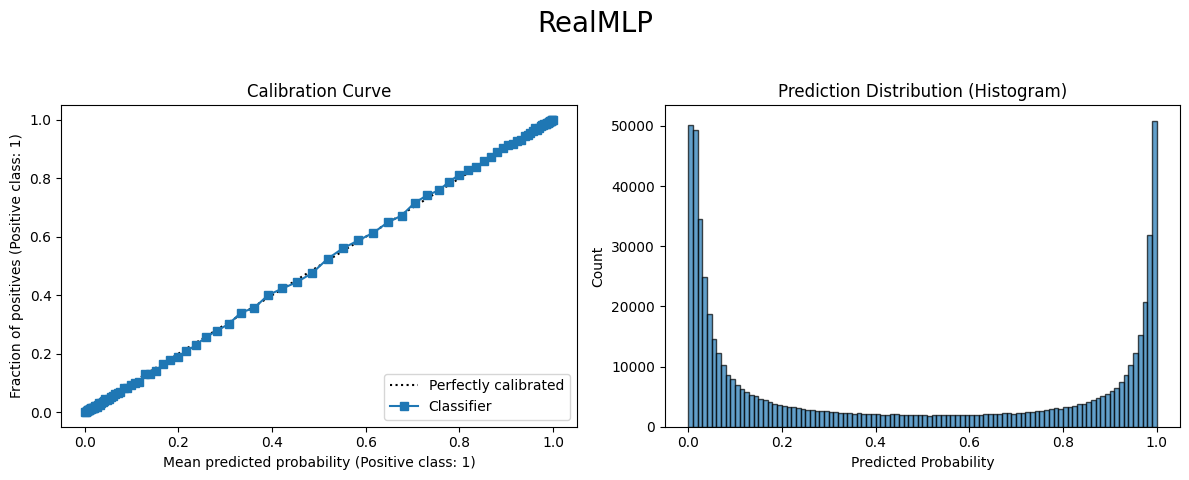

In [9]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5)) 
plt.suptitle('RealMLP', fontsize=20) 

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; background: linear-gradient(90deg, #0d9488, #06b6d4); color:white; font-family: Arial Black;"><b>9. Evaluation and Submission</b></div>

In [10]:
total_oof_score = roc_auc_score(y, oof_preds) 

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC: {total_oof_score:.5f}")
print(f"Mean Fold Score: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")
print("="*40)


Overall OOF ROC-AUC: 0.95553
Mean Fold Score: 0.95567 (+/- 0.00049)


In [11]:
# Fold Scores Table
fold_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(N_FOLDS)],
    'ROC-AUC': fold_scores
})
fold_df

,Fold,ROC-AUC
0,Fold 1,0.956082
1,Fold 2,0.954824
2,Fold 3,0.955813
3,Fold 4,0.955481
4,Fold 5,0.956174


In [12]:
# pd.DataFrame({'id': train['id'], 'Heart Disease_prob': oof_preds}).to_csv('oof_preds_train.csv', index=False)
# commented out oof generation to strict prevention of submitting the wrong file

submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()

Submission saved!
Shape: (270000, 2)


,id,Heart Disease
0,630000,0.944468
1,630001,0.010972
2,630002,0.989483
3,630003,0.006822
4,630004,0.222550


<div style="background: linear-gradient(90deg, #0d9488, #06b6d4); padding: 20px; border-radius: 10px; text-align: center; color: white; font-size: 18px; font-weight: bold;">
Thank you for reading! If you find this notebook useful, please consider giving it an upvote. 😊
</div>